## Support Vector Regressor 
- You need to handle high-dimensional, nonlinear data with robustness to outliers.
- Uses kernels to capture complex patterns, ignores small errors (within epsilon).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv("./cleaned_property_data.csv")
df.head()

,Property Age,Carpet Area (sq.ft.),Super Buildup Rate (per sq.ft.),Built-Up Area (sq.ft.),Area as per Approved Plan (sq.ft.),Valuation Area (sq.ft.),Super Built-up Area (sq.ft.),Total Value (INR),No of Car Parks,Value of Car Park (INR),...,Configuration_encoded,Condition_encoded,Landmark_Airport,Landmark_Hotel,Landmark_Mall,Landmark_Metro Station,Landmark_Park,Landmark_School,Trend_Ratio,Trend_Score
0,15,-1.351929,-1.113209,-1.354267,-1.365018,-1.354267,-1.408260,-0.996161,2,0.010401,...,1,1,False,False,True,False,False,False,1.151405,0.680708
1,6,-0.872300,-0.811877,-0.855542,-0.857951,-0.855542,-0.909855,-0.785320,2,0.010401,...,2,2,False,False,False,False,True,False,0.992883,0.491104
2,10,-0.848378,-0.833919,-0.839994,-0.851972,-0.839994,-0.826190,-0.787031,2,0.010401,...,2,3,False,False,False,False,True,False,1.110167,0.634329
3,8,0.390764,0.704999,0.377515,0.372642,0.377515,0.371417,0.470919,3,1.234081,...,4,3,False,False,False,False,False,True,1.126486,0.653040
4,3,0.734040,0.476538,0.735114,0.739786,0.735114,0.788548,0.555970,1,-1.213278,...,4,4,False,False,False,False,False,True,0.969054,0.461394


In [3]:
X = df.drop(columns=["Super Buildup Rate (per sq.ft.)"], errors="ignore")
y = df["Super Buildup Rate (per sq.ft.)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### SVR Parameters

1. kernel='rbf'
   - Kernel function transforms data for capturing non-linear relations.
   - 'rbf' (Radial Basis Function) is most common, works well for complex patterns.
   - Other options: 'linear', 'poly', 'sigmoid'.

2. C=1.0
   - Regularization parameter controlling trade-off between bias & variance.
   - High C → Fits data more strictly (low bias, high variance, risk of overfitting).
   - Low C → Allows more tolerance to errors (higher bias, lower variance, better generalization).

3. gamma=0.1
   - Defines influence of a single training point in RBF kernel.
   - Low gamma → Wide influence, smoother model.
   - High gamma → Narrow influence, can overfit to noise.

4. epsilon=0.1
   - Defines epsilon-insensitive tube around the regression line.
   - Errors within ±epsilon are ignored (no penalty).
   - Small epsilon → More precise fit, risk of overfitting.
   - Large epsilon → Smoother predictions, tolerates small errors.



In [9]:
svr = SVR(kernel='rbf',C=1.0, gamma=0.1, epsilon=0.1)
svr.fit(X_train, y_train)

SVR(gamma=0.1)

In [10]:
y_pred = svr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Squared Error: 0.0600
Mean Absolute Error: 0.1700
R^2 Score: 0.9344


## Visaulizations

### 1. Regression plot 

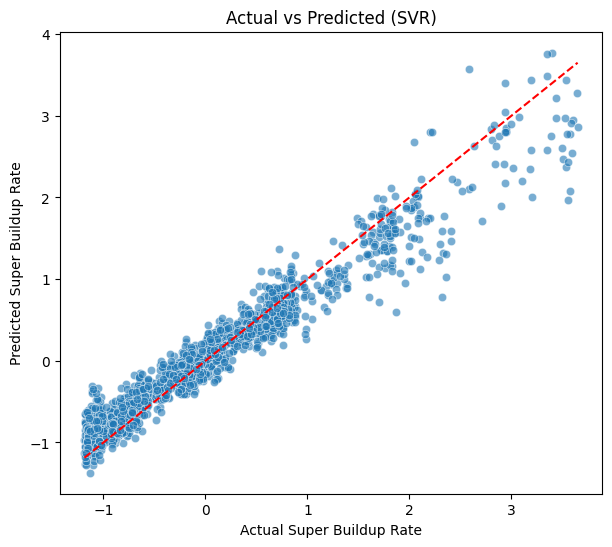

In [11]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45° line
plt.xlabel("Actual Super Buildup Rate")
plt.ylabel("Predicted Super Buildup Rate")
plt.title("Actual vs Predicted (SVR)")
plt.show()

### 2. Residuals plot

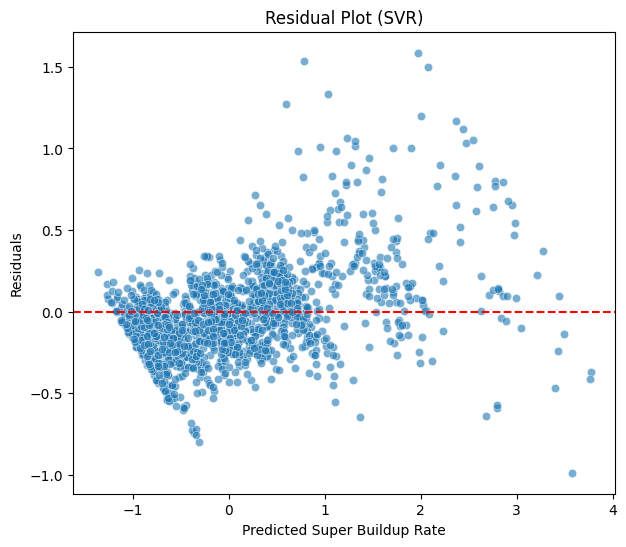

In [12]:
residuals = y_test - y_pred
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Super Buildup Rate")
plt.ylabel("Residuals")
plt.title("Residual Plot (SVR)")
plt.show()

### 3. Error distribution

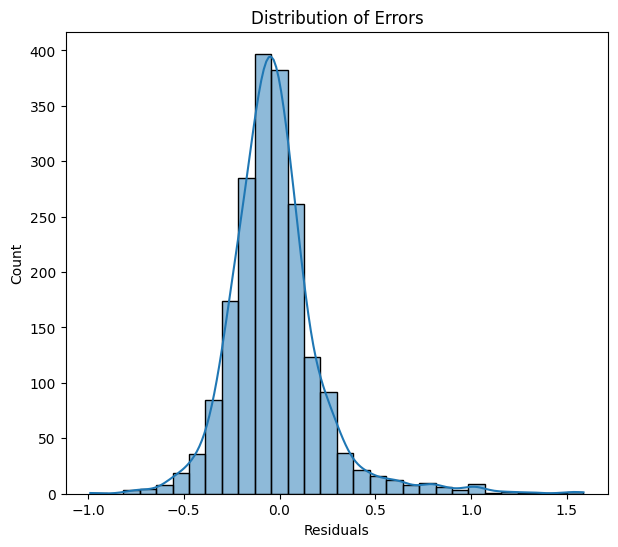

In [19]:
plt.figure(figsize=(7,6))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Residuals")
plt.title("Distribution of Errors")
plt.show()